# Python Lesson 53: Central Limit Theorem

**Concept page:** `wiki/concepts/central-limit-theorem.md` · **Area:** statistics

**You will be able to:**
- draw sample means from different populations
- verify mean μ and standard error σ/√n
- see the Cauchy counter-example

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Gaussian population

In [2]:
rng=np.random.default_rng(0)
pop=rng.normal(10,5,100000)
def sample_means(pop,n,k=5000): return np.array([rng.choice(pop,n).mean() for _ in range(k)])
m=sample_means(pop,50); print(m.mean(), m.std(), 5/np.sqrt(50))

10.022089043278985 0.6967789244670495 0.7071067811865475


## 2. Skewed populations: binomial and Poisson

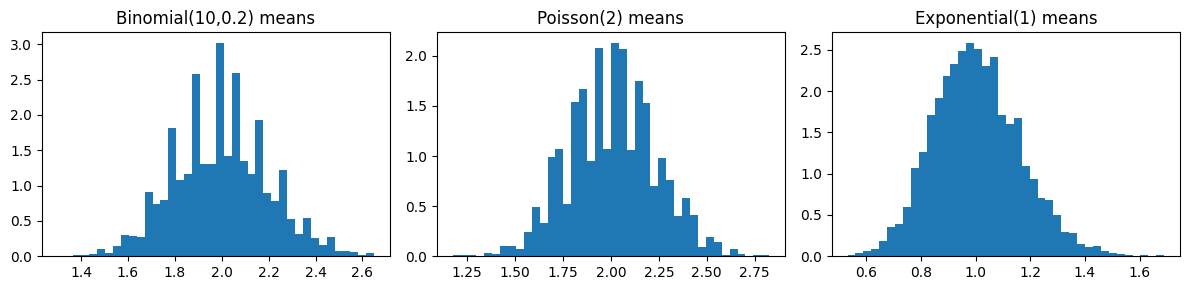

In [3]:
fig,axs=plt.subplots(1,3,figsize=(12,3))
for ax,(name,pp) in zip(axs,[("Binomial(10,0.2)",rng.binomial(10,0.2,100000)),("Poisson(2)",rng.poisson(2,100000)),("Exponential(1)",rng.exponential(1,100000))]):
    mm=sample_means(pp.astype(float),40); ax.hist(mm,bins=40,density=True); ax.set_title(name+" means")
plt.tight_layout(); plt.show()

## 3. Cauchy: no finite variance, CLT fails

In [4]:
cau=rng.standard_cauchy(100000)
for n in (10,100,1000): mm=sample_means(cau,n,2000); print(n,"spread of means (IQR):",np.subtract(*np.percentile(mm,[75,25])))   # does not shrink like 1/sqrt(n)

10 spread of means (IQR): 1.9897031489748338
100 spread of means (IQR): 1.999893240192419
1000 spread of means (IQR): 1.7971099943006918


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 9 mean (មធ្យមស្ថិតិ) is the statistic whose behaviour the CLT describes.

In [5]:
print(np.mean([18,12,30,26,38,42,48]))

30.571428571428573


## Exercises

**Exercise 1.** Check the standard error shrinks like 1/sqrt(n): compare n=25 and n=100 for the Gaussian population.

In [6]:
# your code here

**Exercise 2.** What fraction of sample means (n=50) lie within 2 SE of mu? (~0.95)

In [7]:
# your code here

## Solutions
*(Try the exercises first!)*

In [8]:
# Solution 1
s25=sample_means(pop,25).std(); s100=sample_means(pop,100).std(); print(s25/s100); assert 1.8<s25/s100<2.2

2.002589534154333


In [9]:
# Solution 2
m=sample_means(pop,50); f=np.mean(abs(m-10)<2*5/np.sqrt(50)); print(f); assert 0.93<f<0.97

0.9582
